
# Predicting Child Stunting Growth in Kenya

## Problem Statement

Predicting stunting severity (severe stunting, moderate stunting, or normal growth, per WHO height-for-age z-score thresholds of -3 SD and -2 SD) for Kenyan children under five, using household, maternal, and child-health variables from the Kenya Demographic and Health Survey Children's Recode — including region, residence type, mother's education, household wealth index, drinking water source, toilet facility, birth order and spacing, birth weight, breastfeeding duration, and antenatal care history. Primary metric: macro-averaged F1 score, reported alongside one-vs-rest ROC-AUC and per-class precision/recall.

## The Problem

Stunting — being too short for one's age because of chronic undernutrition —
still affects roughly one in five children under five in Kenya. A stunted
child faces lifelong risks: weaker immunity, slower cognitive development,
and lower earning potential as an adult. Health workers and parents need a
reliable way to spot which children are stunted, and how severely, early
enough to act — but with limited time and resources, they cannot manually
review every household's full survey record to catch every at-risk child.

## Our Solution

We build a machine learning model that takes a child's household, maternal,
and health-history information and classifies their growth status as
**severe stunting**, **moderate stunting**, or **normal growth**. Beyond the
prediction itself, each outcome is paired with practical guidance: children
flagged as stunted (severe or moderate) receive diet and care recommendations
aimed at correcting growth faltering, while children predicted to be growing
normally receive guidance to continue their current feeding practices. The
goal is a tool that medical practitioners and parents can use to decide, at a
glance, whether a child's diet needs to change and how.

## Data Source

The data comes from the **Kenya Demographic and Health Survey (KDHS)**,
specifically its **Children's Recode** file — a nationally representative
household survey that records one row per live birth reported by an
interviewed woman (`bidx` = birth order index within her birth history,
`caseid` identifies the mother). For children under five it captures health,
nutrition, immunization, and anthropometric (height/weight) measurements
alongside household and maternal background variables. The Children's Recode
was originally distributed as a Stata file (`KEKR8CFL.DTA`, with column
layout described in `KEKR8CFL.DCT`); we use those two files only once, up
front, to decode Stata's numeric variable and value codes into their
plain-English meanings — from that point on we work entirely from CSV.

**Inputs used**

| File | Role |
|---|---|
| `child_recode_raw.csv` | the raw data we are cleaning (19,530 rows × 1,312 columns) |
| `variable_labels.csv` | plain-English description for every variable code (`v106` -> "Highest educational level"), used to understand and rename the columns we keep |



In [ ]:

# --- Imports -----------------------------------------------------------
!pip install pyreadstat
import re
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyreadstat  # only used to read METADATA (variable/value labels) from the .dta file
from sklearn.exceptions import UndefinedMetricWarning

# In a few cross-validation folds, "severe stunting" (the rarest class) can
# end up with zero predicted samples for a weaker model; sklearn's macro
# precision/recall then emits a warning and reports 0.0 for that class,
# which is the mathematically correct (if uninformative) value - suppressed
# here so it doesn't clutter otherwise-successful cell output.
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid")



In [ ]:
#Load Data
# --- File locations ------------------------------------------------------
# Adjust these if your files live somewhere else. All four inputs are expected
# to sit in the same folder as this notebook by default.
from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = Path("/content/drive/MyDrive/Ngao_labs/capstone/child recode")
RAW_CSV        = DATA_DIR / "child_recode_raw.csv"
LABELS_CSV     = DATA_DIR / "variable_labels.csv"
DTA_FILE       = DATA_DIR / "KEKR8CFL.DTA"

OUT_DIR = Path("/content/drive/MyDrive/Ngao_labs/capstone/child recode/processed")
OUT_DIR.mkdir(exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

folder = "/content/drive/MyDrive/Ngao_labs/capstone/child recode"
for f in os.listdir(folder):
    print(f)

KEKR8CFL.FRW
KEKR8CFL.MAP
KEKR8CFL.DO
KEKR8CFL.DCT
KEKR8CFL.DTA
KEKR8CFL.FRQ
child_recode_full.csv
child_recode_raw.csv
value_labels.csv
variable_labels.csv
selected_features_value_labels.csv
cleaned_output
processed


In [ ]:
import os
processed = "/content/drive/MyDrive/Ngao_labs/capstone/child recode/processed"
for f in os.listdir(processed):
    print(f)

feature_engineering_log.csv
child_recode_model_ready.csv
child_recode_clean.csv
data_dictionary.json
missing_code_recode_log.csv
dropped_columns_log.csv
child_recode_labeled.csv
bridge_02_to_03.joblib



# Part 2: Exploratory Data Analysis (EDA)

With a clean, readable table in hand, this part looks at what the data
actually contains: the shape of the target variable, how much is missing
in each predictor, how the categorical predictors are distributed, and how
the target relates to a few of the strongest candidate predictors. The
goal is to surface anything that should inform feature engineering in
Part 3 — not to draw final conclusions.

This part reloads `child_recode_labeled.csv` from disk, so it can be run
independently of Part 1.


In [ ]:
df = pd.read_csv(OUT_DIR / "child_recode_labeled.csv")
print(f"Loaded {df.shape[0]:,} rows x {df.shape[1]:,} columns for EDA.")
df.info(memory_usage=False)


Loaded 19,530 rows x 25 columns for EDA.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19530 entries, 0 to 19529
Data columns (total 25 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   child id                                     19530 non-null  object 
 1   case id                                      19530 non-null  object 
 2   region                                       19530 non-null  object 
 3   type of residence                            19530 non-null  object 
 4   highest level of education                   19530 non-null  object 
 5   source of drinking water                     19530 non-null  object 
 6   type of toilet facility                      19456 non-null  object 
 7   sex of household head                        19530 non-null  object 
 8   wealth index                                 19530 non-null  object 
 9   child is twin                  


## 2.1 Target variable: height-for-age z-score

The `height-for-age z-score` column already runs in actual standard
deviations (Part 1 converted it from DHS's *100-scaled storage). WHO
defines **stunting** as HAZ < -2 SD and **severe stunting** as HAZ < -3 SD
versus the WHO child growth reference — those thresholds are drawn on the
histogram below.


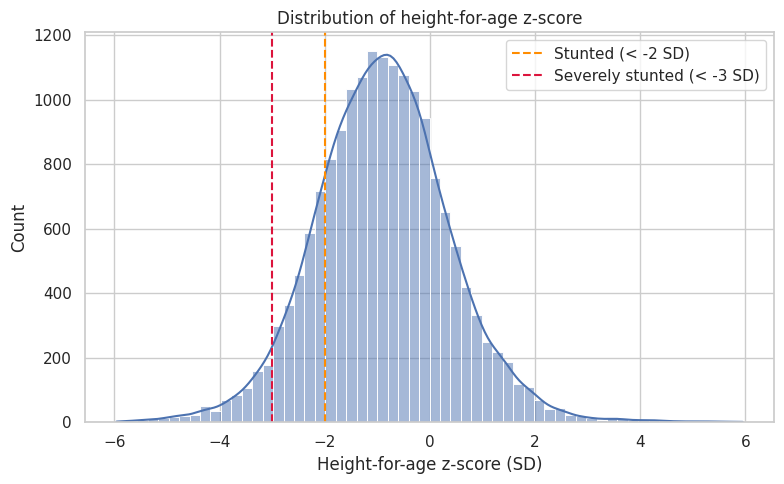

Valid HAZ measurements: 17,327 / 19,530 (88.7%)
Stunted (< -2 SD):          3,122  (16.0%)
Severely stunted (< -3 SD): 751  (3.8%)


In [ ]:

haz = df["height-for-age z-score"]

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(haz.dropna(), bins=60, kde=True, ax=ax, color="#4C72B0")
ax.axvline(-2, color="darkorange", linestyle="--", label="Stunted (< -2 SD)")
ax.axvline(-3, color="crimson", linestyle="--", label="Severely stunted (< -3 SD)")
ax.set_xlabel("Height-for-age z-score (SD)")
ax.set_title("Distribution of height-for-age z-score")
ax.legend()
plt.tight_layout()
plt.show()

n_valid = haz.notna().sum()
print(f"Valid HAZ measurements: {n_valid:,} / {len(haz):,} ({100 * n_valid / len(haz):.1f}%)")
print(f"Stunted (< -2 SD):          {(haz < -2).sum():,}  ({100 * (haz < -2).mean():.1f}%)")
print(f"Severely stunted (< -3 SD): {(haz < -3).sum():,}  ({100 * (haz < -3).mean():.1f}%)")



## 2.2 HAZ severity categories

Rather than working with the raw score, `stunting category` (built in
Part 1 §13) buckets it into three severity labels used throughout the
rest of this notebook:

| Category | HAZ range |
|---|---|
| **Severe stunting** | below -3 |
| **Moderate stunting** | -3 to -2 |
| **Normal growth** | -2 to 6 |


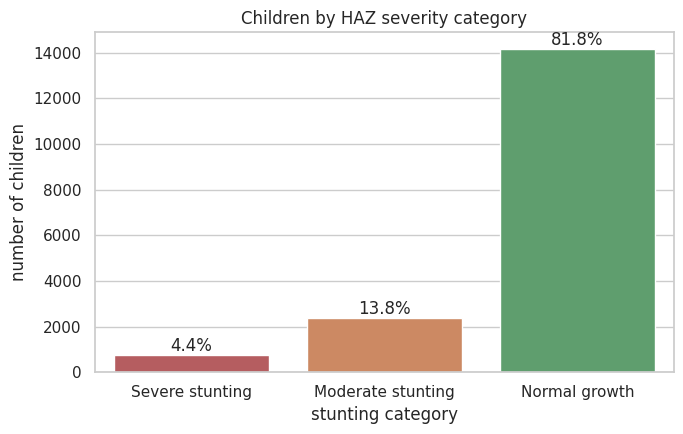

,count,pct_of_valid
stunting category,,
Severe stunting,761,4.4
Moderate stunting,2390,13.8
Normal growth,14176,81.8


In [ ]:

HAZ_CATEGORY_LABELS = ["Severe stunting", "Moderate stunting", "Normal growth"]

category_counts = df["stunting category"].value_counts().reindex(HAZ_CATEGORY_LABELS)
category_pct = (df["stunting category"].value_counts(normalize=True) * 100).reindex(HAZ_CATEGORY_LABELS)

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.barplot(x=category_counts.index, y=category_counts.values, hue=category_counts.index,
            order=HAZ_CATEGORY_LABELS, ax=ax, palette=["#C44E52", "#DD8452", "#55A868"], legend=False)
ax.set_ylabel("number of children")
ax.set_title("Children by HAZ severity category")
for i, (count, pct) in enumerate(zip(category_counts, category_pct)):
    ax.text(i, count, f"{pct:.1f}%", ha="center", va="bottom")
plt.tight_layout()
plt.show()

pd.DataFrame({"count": category_counts, "pct_of_valid": category_pct.round(1)})



## 2.3 Missingness across the feature set

Survey-based predictors (antenatal care, breastfeeding, birth weight) are
often only collected for a subset of children, so uneven missingness here
is expected. This chart shows which columns will need the most attention
in Part 3.


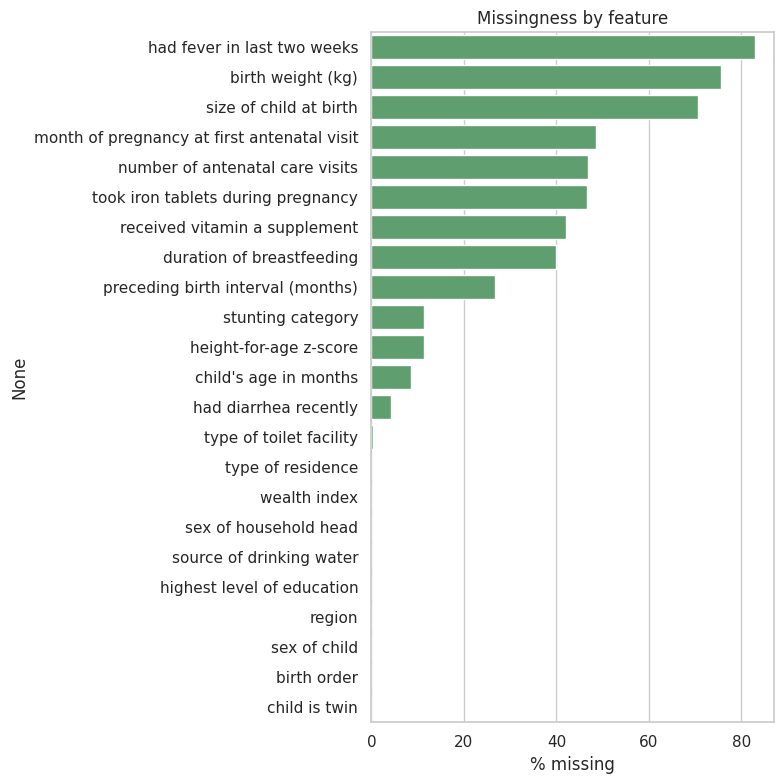

In [ ]:

feature_cols = [c for c in df.columns if c not in ("child id", "case id")]

missing_pct = (df[feature_cols].isnull().mean() * 100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 8))
sns.barplot(x=missing_pct.values, y=missing_pct.index, ax=ax, color="#55A868")
ax.set_xlabel("% missing")
ax.set_title("Missingness by feature")
plt.tight_layout()
plt.show()

missing_pct.to_frame("pct_missing").to_csv(OUT_DIR / "eda_missingness_by_feature.csv")


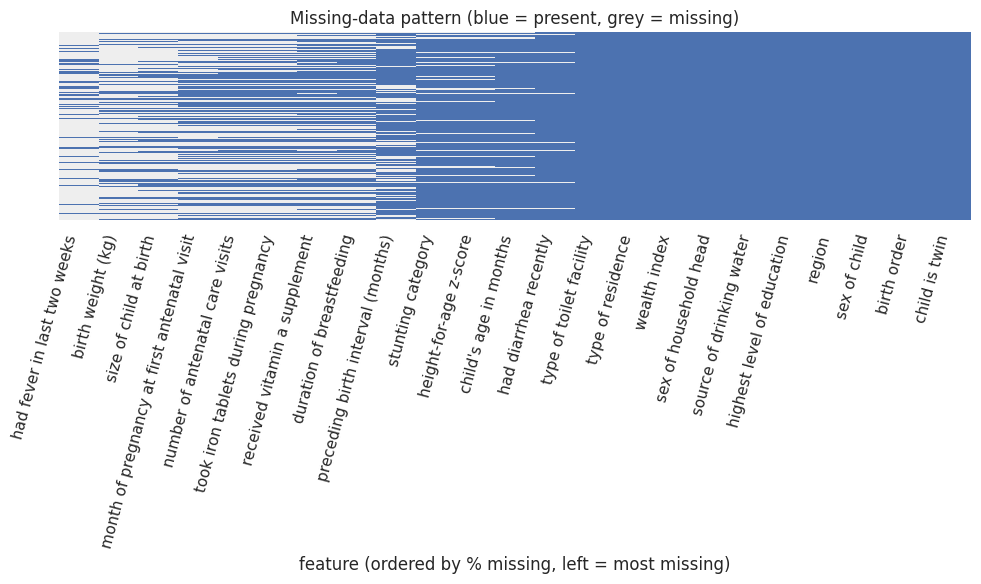

In [ ]:

# A heatmap shows both how much is missing (the bar chart above) and where
# it's missing (whether it clusters in the same rows/children) in one view.
# Columns are ordered by missingness rate so the pattern reads left-to-right.
from matplotlib.colors import ListedColormap

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(df[missing_pct.index].isnull(), cbar=False, yticklabels=False,
            cmap=ListedColormap(["#4C72B0", "#EEEEEE"]), ax=ax)
ax.set_title("Missing-data pattern (blue = present, grey = missing)")
ax.set_xlabel("feature (ordered by % missing, left = most missing)")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()



## 2.4 Summary statistics for continuous predictors


In [ ]:

continuous_vars = ["child's age in months", "birth order", "preceding birth interval (months)",
                    "birth weight (kg)", "month of pregnancy at first antenatal visit",
                    "number of antenatal care visits", "height-for-age z-score"]
continuous_vars = [c for c in continuous_vars if c in df.columns]

summary_stats = df[continuous_vars].describe().T
summary_stats.to_csv(OUT_DIR / "eda_summary_stats.csv")
summary_stats


,count,mean,std,min,25%,50%,75%,max
child's age in months,17847.0,28.441923,17.365270,0.00,13.000,28.0,43.00,59.00
birth order,19530.0,3.210958,2.237028,1.00,1.000,3.0,4.00,15.00
preceding birth interval (months),14305.0,46.689269,31.691004,8.00,25.000,37.0,59.00,309.00
birth weight (kg),4755.0,3.180760,0.622111,0.60,2.900,3.2,3.50,6.00
month of pregnancy at first antenatal visit,10027.0,4.440610,1.629673,1.00,3.000,4.0,6.00,10.00
number of antenatal care visits,10401.0,4.064898,1.816728,0.00,3.000,4.0,5.00,20.00
height-for-age z-score,17327.0,-0.894771,1.282488,-5.96,-1.725,-0.9,-0.11,5.95



## 2.5 Categorical / ordinal predictor distributions


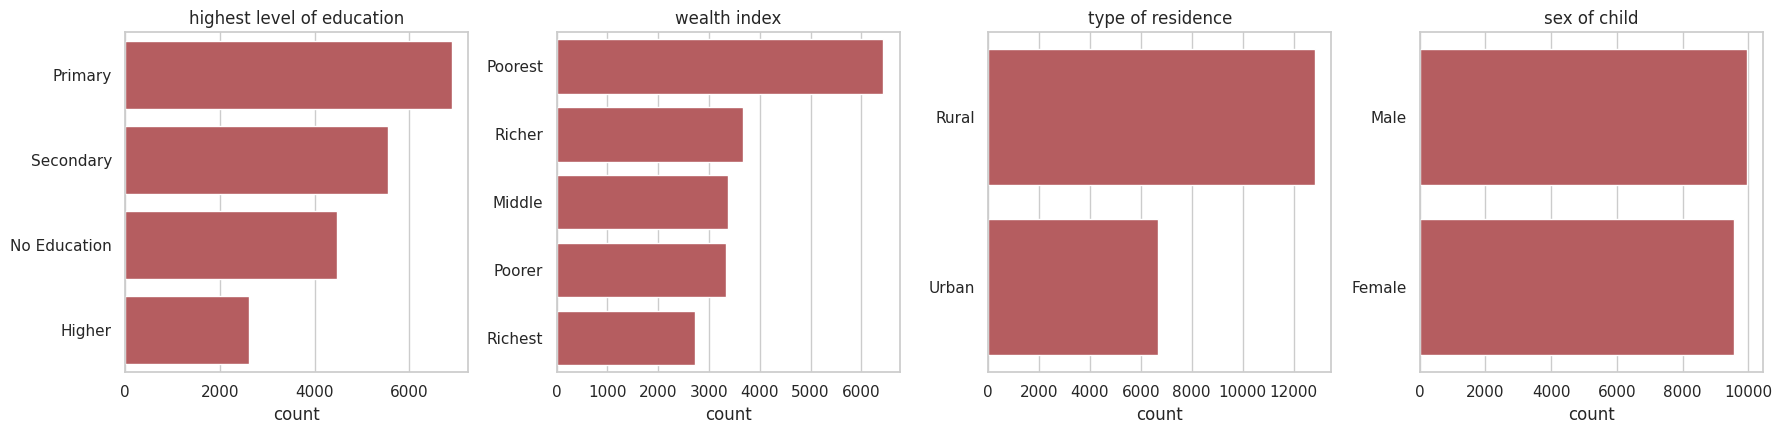

In [ ]:

cat_vars_to_plot = ["highest level of education", "wealth index", "type of residence", "sex of child"]
cat_vars_to_plot = [c for c in cat_vars_to_plot if c in df.columns]

fig, axes = plt.subplots(1, len(cat_vars_to_plot), figsize=(4.5 * len(cat_vars_to_plot), 4.5))
for ax, col in zip(axes, cat_vars_to_plot):
    order = df[col].value_counts().index
    sns.countplot(y=df[col], order=order, ax=ax, color="#C44E52")
    ax.set_title(col)
    ax.set_ylabel("")
    ax.set_xlabel("count")
plt.tight_layout()
plt.show()



## 2.6 Target vs. key categorical predictors

Boxplots of HAZ across wealth quintile, mother's education, and
urban/rural residence — three of the strongest documented predictors of
stunting — to confirm the expected direction of each relationship before
they go into a model.


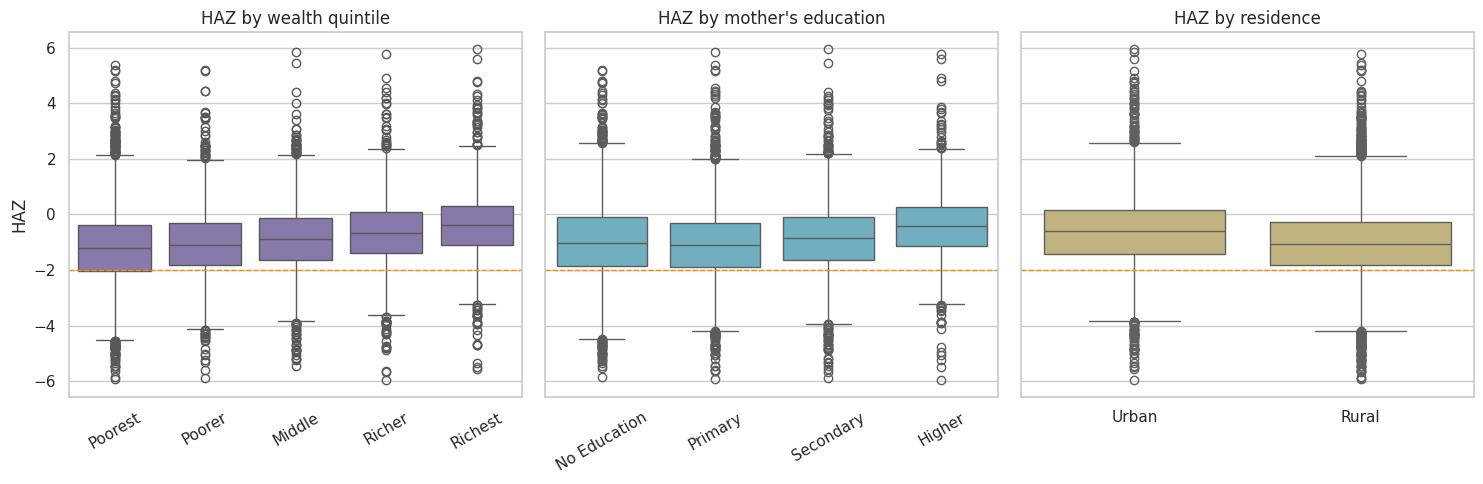

In [ ]:

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

wealth_order = ["Poorest", "Poorer", "Middle", "Richer", "Richest"]
sns.boxplot(data=df, x="wealth index", y="height-for-age z-score", order=wealth_order, ax=axes[0], color="#8172B2")
axes[0].set_title("HAZ by wealth quintile")
axes[0].tick_params(axis="x", rotation=30)

edu_order = ["No Education", "Primary", "Secondary", "Higher"]
sns.boxplot(data=df, x="highest level of education", y="height-for-age z-score", order=edu_order, ax=axes[1], color="#64B5CD")
axes[1].set_title("HAZ by mother's education")
axes[1].tick_params(axis="x", rotation=30)

sns.boxplot(data=df, x="type of residence", y="height-for-age z-score", ax=axes[2], color="#CCB974")
axes[2].set_title("HAZ by residence")

for ax in axes:
    ax.axhline(-2, color="darkorange", linestyle="--", linewidth=1)
    ax.set_xlabel("")
    ax.set_ylabel("HAZ")

plt.tight_layout()
plt.show()



## 2.7 Correlation among numeric predictors and the target

Limited, at this stage, to variables that are naturally numeric.
Categorical predictors like region, education, or wealth quintile aren't
meaningfully correlatable in text form — they get encoded in Part 3/4
instead.


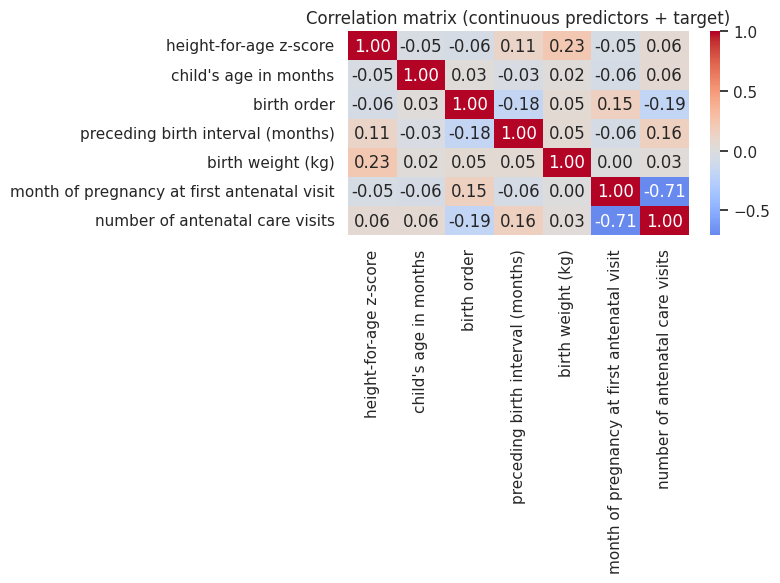

,corr_with_HAZ
birth weight (kg),0.225458
preceding birth interval (months),0.112515
number of antenatal care visits,0.061449
birth order,-0.055688
month of pregnancy at first antenatal visit,-0.053366
child's age in months,-0.047102


In [ ]:

corr_vars = ["height-for-age z-score", "child's age in months", "birth order",
             "preceding birth interval (months)", "birth weight (kg)",
             "month of pregnancy at first antenatal visit", "number of antenatal care visits"]
corr_vars = [c for c in corr_vars if c in df.columns]

corr = df[corr_vars].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f", ax=ax)
ax.set_title("Correlation matrix (continuous predictors + target)")
plt.tight_layout()
plt.show()

corr["height-for-age z-score"].drop("height-for-age z-score").sort_values(key=abs, ascending=False).to_frame("corr_with_HAZ")



## 2.8 Geographic pattern: stunting by region

Stunting is well documented to vary sharply by county in Kenya (driven by
food security, health-system access, and water/sanitation infrastructure,
which themselves vary geographically). This is also the view we come back
to in Part 7's disaggregated evaluation, to check whether the model's
accuracy holds up evenly across regions or drops in specific counties.


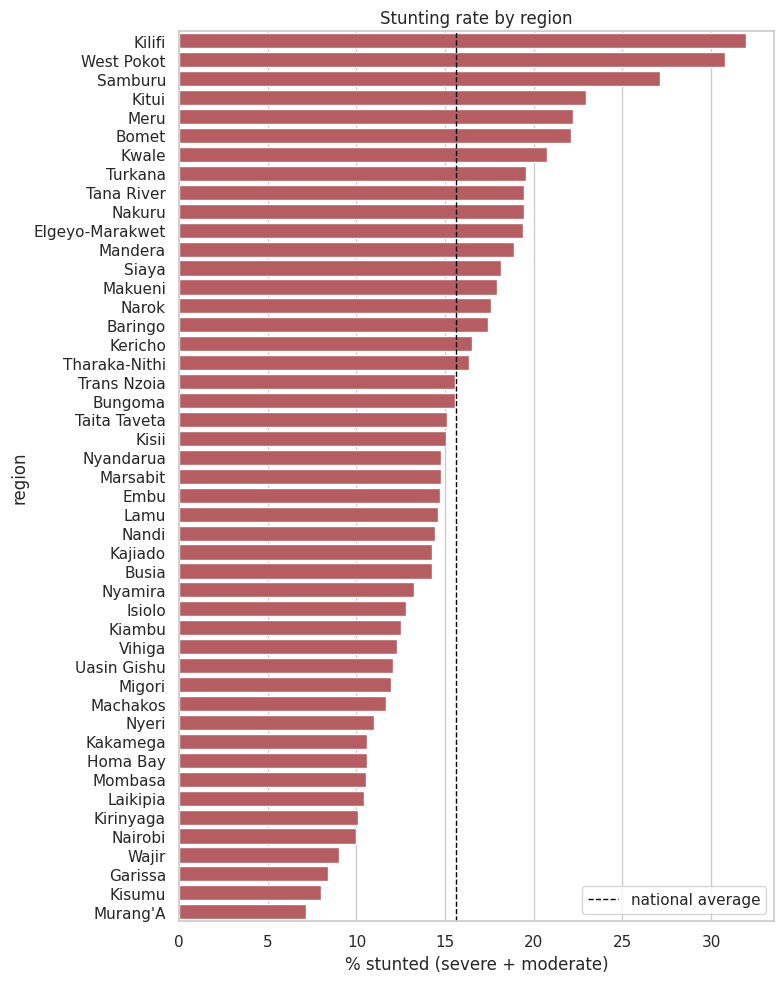

In [ ]:

region_stunting = (
    df.assign(is_stunted=df["stunting category"].isin(["Severe stunting", "Moderate stunting"]))
      .groupby("region")["is_stunted"].mean()
      .sort_values(ascending=False) * 100
)

fig, ax = plt.subplots(figsize=(8, 10))
sns.barplot(x=region_stunting.values, y=region_stunting.index, ax=ax, color="#C44E52")
ax.axvline(region_stunting.mean(), color="black", linestyle="--", linewidth=1, label="national average")
ax.set_xlabel("% stunted (severe + moderate)")
ax.set_title("Stunting rate by region")
ax.legend()
plt.tight_layout()
plt.show()
